<a href="https://colab.research.google.com/github/sarahchaewon/DSRP_/blob/main/new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

policy = pd.read_csv("https://raw.githubusercontent.com/sarahchaewon/DSRP_/main/ai_policy_and_ethics.csv")
respondents = pd.read_csv("https://raw.githubusercontent.com/sarahchaewon/DSRP_/main/respondents.csv")
salary = pd.read_csv("https://raw.githubusercontent.com/sarahchaewon/DSRP_/main/salary_and_satisfaction.csv")

In [3]:
# merge files into one dataframe
df = respondents.merge(policy, on = 'respondent_id').merge(salary, on = 'respondent_id')

In [4]:
# filter healthcare industry only
df = df[df['industry'] == 'Healthcare']

In [5]:
df.head()

,respondent_id,survey_year,age,gender,country,education_level,job_role,industry,company_size,years_of_experience,...,trust_in_ai_decisions,annual_salary_usd,salary_change_yoy_pct,job_satisfaction_score,career_growth_outlook,ai_job_replacement_fear,job_search_status,received_ai_related_promotion,work_life_balance_score,burnout_level
24,R00025,2025,25,Male,France,PhD,ML Engineer,Healthcare,1001-5000,5,...,Moderate,186100.0,16.0,4,Positive,Neutral,Not looking,No,3,NaN
52,R00053,2025,42,Female,United States,Self-taught / Bootcamp,ML Engineer,Healthcare,5000+,4,...,Moderate,135700.0,6.6,3,Neutral,Somewhat likely,Not looking,No,4,Mild
65,R00066,2025,38,Male,Sweden,Master's,DevOps / MLOps Engineer,Healthcare,201-1000,19,...,Moderate,213100.0,-0.0,4,Neutral,Somewhat likely,Not looking,Yes,3,Moderate
67,R00068,2025,27,Female,Japan,Master's,Product Manager,Healthcare,11-50,14,...,High,112900.0,21.0,5,Positive,Somewhat likely,Not looking,No,2,Severe
70,R00071,2025,34,Male,Poland,Master's,Business Analyst,Healthcare,201-1000,9,...,Moderate,126900.0,-4.4,5,Negative,Unlikely,Not looking,No,3,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1163 entries, 24 to 11967
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   respondent_id                  1163 non-null   object 
 1   survey_year                    1163 non-null   int64  
 2   age                            1163 non-null   int64  
 3   gender                         1163 non-null   object 
 4   country                        1163 non-null   object 
 5   education_level                1163 non-null   object 
 6   job_role                       1163 non-null   object 
 7   industry                       1163 non-null   object 
 8   company_size                   1163 non-null   object 
 9   years_of_experience            1163 non-null   int64  
 10  remote_work_status             1163 non-null   object 
 11  company_has_ai_policy          1163 non-null   object 
 12  ai_bias_concern_level          1163 non-null   int6

In [ ]:
# no duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# 229 missing values for burnout_level
df.isna().sum()

,0
respondent_id,0
survey_year,0
age,0
gender,0
country,0
education_level,0
job_role,0
industry,0
company_size,0
years_of_experience,0


In [7]:
# check for standardization for the categorical column data
cat_cols = ['gender', 'country', 'education_level', 'job_role', 'company_size',
            'remote_work_status', 'company_has_ai_policy', 'supports_ai_regulation',
            'has_experienced_ai_misuse', 'trust_in_ai_decisions', 'career_growth_outlook',
            'ai_job_replacement_fear', 'job_search_status', 'received_ai_related_promotion']

for col in cat_cols:
    print(col, ':', df[col].unique())

gender : ['Male' 'Female' 'Prefer not to say' 'Non-binary']
country : ['France' 'United States' 'Sweden' 'Japan' 'Poland' 'Canada' 'Indonesia'
 'China' 'UAE' 'India' 'Germany' 'United Kingdom' 'Australia' 'Brazil'
 'South Korea' 'South Africa' 'Mexico' 'Spain' 'Netherlands' 'Italy'
 'Philippines' 'Nigeria' 'Kenya' 'Singapore' 'Israel']
education_level : ['PhD' 'Self-taught / Bootcamp' "Master's" "Bachelor's" 'High School']
job_role : ['ML Engineer' 'DevOps / MLOps Engineer' 'Product Manager'
 'Business Analyst' 'Student / Intern' 'Data Analyst' 'Software Engineer'
 'Data Scientist' 'Data Engineer' 'Full-Stack Developer'
 'Engineering Manager' 'AI Ethics / Policy' 'UX Designer' 'AI Researcher'
 'Consultant']
company_size : ['1001-5000' '5000+' '201-1000' '11-50' '51-200' '1-10']
remote_work_status : ['Hybrid' 'On-site' 'Fully Remote']
company_has_ai_policy : ['No' 'Yes - formal' "Don't know" 'Yes - informal']
supports_ai_regulation : ['Disagree' 'Neutral' 'Agree' 'Strongly agree' 'Stron

In [ ]:
# check outliers or nonsensical data for numerical column data
df.describe()

,survey_year,age,years_of_experience,ai_bias_concern_level,data_privacy_concern_level,annual_salary_usd,salary_change_yoy_pct,job_satisfaction_score,work_life_balance_score
count,1163.000000,1163.000000,1163.000000,1163.000000,1163.000000,1163.000000,1163.000000,1163.000000,1163.000000
mean,2024.914015,31.564058,9.053310,3.545142,3.865864,114402.149613,5.476956,3.604471,3.457438
std,0.768015,7.649597,6.912578,1.121830,1.028457,77177.350604,8.082471,1.151238,1.098678
min,2024.000000,18.000000,0.000000,1.000000,1.000000,5000.000000,-24.400000,1.000000,1.000000
25%,2024.000000,26.000000,4.000000,3.000000,3.000000,49850.000000,0.200000,3.000000,3.000000
50%,2025.000000,31.000000,7.000000,4.000000,4.000000,100800.000000,5.400000,4.000000,4.000000
75%,2026.000000,37.000000,12.000000,4.000000,5.000000,166600.000000,10.850000,4.000000,4.000000
max,2026.000000,53.000000,35.000000,5.000000,5.000000,415800.000000,34.300000,5.000000,5.000000


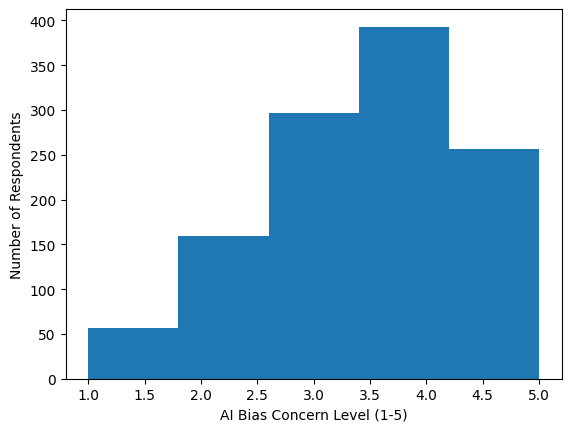

In [11]:
plt.hist(df['ai_bias_concern_level'], bins=5)
plt.xlabel('AI Bias Concern Level (1-5)')
plt.ylabel('Number of Respondents')
plt.show()

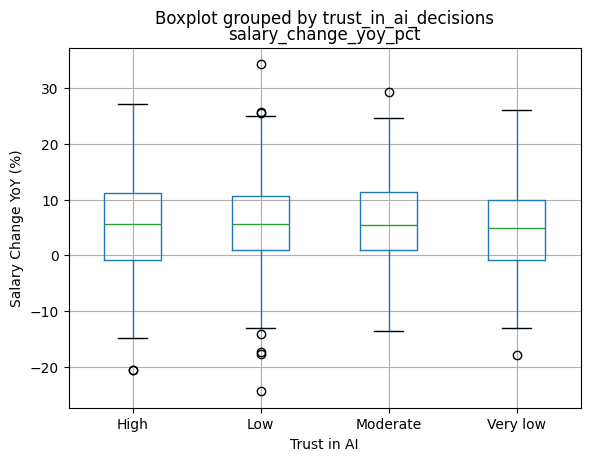

In [12]:
df.boxplot(column='salary_change_yoy_pct', by='trust_in_ai_decisions')
plt.xlabel('Trust in AI')
plt.ylabel('Salary Change YoY (%)')
plt.show()

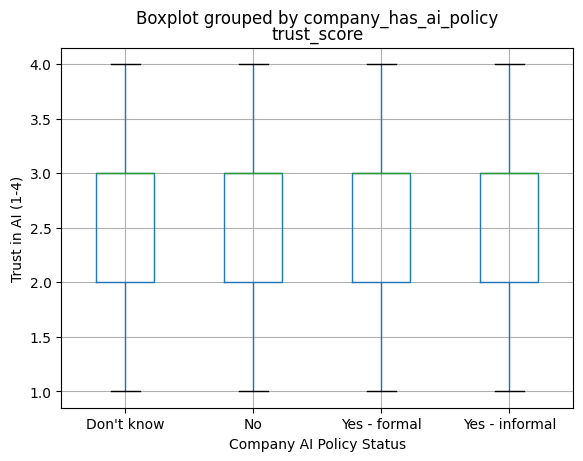

In [14]:
df.boxplot(column='trust_score', by='company_has_ai_policy')
plt.xlabel('Company AI Policy Status')
plt.ylabel('Trust in AI (1-4)')
plt.show()

In [8]:
# encode trust_in_ai_decisions into numbers
trust_map = {'Very low': 1, 'Low': 2, 'Moderate': 3, 'High': 4}
df['trust_score'] = df['trust_in_ai_decisions'].map(trust_map)

# encode ai_job_replacement_fear into numbers
fear_map = {'Very unlikely': 1, 'Unlikely': 2, 'Neutral': 3, 'Somewhat likely': 4, 'Very likely': 5}
df['fear_score'] = df['ai_job_replacement_fear'].map(fear_map)

In [9]:
# Hypothesis Test 1: ANOVA
import scipy.stats as stats

groups = df.groupby('trust_in_ai_decisions')['salary_change_yoy_pct']
high = groups.get_group('High')
low = groups.get_group('Low')
moderate = groups.get_group('Moderate')
verylow = groups.get_group('Very low')

f_stat, p_val = stats.f_oneway(high, low, moderate, verylow)
print('p =', p_val)

ANOVA p = 0.6937391750341302


In [13]:
# Hypothesis Test 2: Chi-squared
con_table = pd.crosstab(df['company_has_ai_policy'], df['trust_in_ai_decisions'])
result = stats.chi2_contingency(con_table)
result.pvalue

np.float64(0.11614673397785921)

In [14]:
# Linear Regression
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

features = df[['fear_score']]
label = df['salary_change_yoy_pct']
X_train, X_test, y_train, y_test = model_selection.train_test_split(features, label, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)
pred = reg.predict(X_test)

In [15]:
r2_score(y_test, pred)

-0.006287404923276618

In [16]:
mean_squared_error(y_test, pred)

70.12372381985739

In [17]:
# KNN Classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

features2 = df[['fear_score', 'ai_bias_concern_level']]
label2 = df['trust_in_ai_decisions']
X_train2, X_test2, y_train2, y_test2 = model_selection.train_test_split(features2, label2, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train2, y_train2)
pred2 = model.predict(X_test2)

In [18]:
metrics.accuracy_score(y_test2, pred2)

0.19742489270386265